## Paso 0: Importar librerías

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)


# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## Paso 1: Cargar datos

El dataset contiene **205 coches** con 26 variables: características físicas del vehículo, motor y precio.
Es un dataset de regresión clásico: queremos predecir el precio a partir de las especificaciones del coche.

In [2]:
df = pd.read_csv("CarPrice_Assignment.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [4]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Paso 2: Definición del problema

**Variable objetivo:** `price`

`price` es un valor numérico continuo → **problema de regresión**.

Queremos construir un modelo que, dadas las especificaciones técnicas de un coche (motor, dimensiones, tipo de carrocería, marca…), sea capaz de estimar su precio de mercado.

In [5]:
TARGET = 'price'

print(f"Valores únicos en price: {df[TARGET].nunique()}")
print(f"Rango: {df[TARGET].min():.0f} — {df[TARGET].max():.0f}")
print(f"Media: {df[TARGET].mean():.0f}  |  Mediana: {df[TARGET].median():.0f}")

Valores únicos en price: 189
Rango: 5118 — 45400
Media: 13277  |  Mediana: 10295


## Paso 3: División de Train y Test

Con 205 filas el dataset es pequeño. Usamos 80/20 para maximizar los datos de entrenamiento.

> ⚠️ Hacemos el split **antes** de cualquier exploración o transformación para no contaminar el test con información del train (data leakage).

**La variable y**= es la variable a estudiar la que queremos predecir(Target) y **la variable X** son todas las demas variables que usa el modelo para predecir.

In [6]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 164 filas
Test:  41 filas


## Paso 4: Limpieza de los datos

En este dataset no hay missings explícitos, pero hay **tres problemas de calidad** que conviene resolver antes del EDA:

1. `car_ID` es un identificador de fila. No aporta información predictiva → eliminar.
2. `CarName` tiene el nombre completo del coche. Podemos extraer la **marca** (primer token) y descartarlo. Además hay **errores tipográficos** que normalizaremos.
3. `cylindernumber` está en texto (`four`, `six`, `three`...) pero es una variable ordinal numérica → convertir a entero.

In [7]:
# Revisar missings
print("Missings por columna:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print("→ Sin valores faltantes en este dataset.")

Missings por columna:
Series([], dtype: int64)
→ Sin valores faltantes en este dataset.


In [8]:
# ── 1. Eliminar car_ID
X_train = X_train.drop(columns=['car_ID'])
X_test  = X_test.drop(columns=['car_ID'])

In [9]:
# ── 2. Extraer marca (CarBrand) desde CarName y corregir typos

def extraer_marca(nombre):
    """Extrae y normaliza la marca del coche desde el campo CarName."""
    marca = str(nombre).split()[0].lower().strip('-')
    
    # Correcciones de typos conocidos en el dataset
    correcciones = {
        'maxda':     'mazda',
        'porcshce':  'porsche',
        'toyouta':   'toyota',
        'vokswagen': 'volkswagen',
        'vw':        'volkswagen',
    }
    return correcciones.get(marca, marca)

X_train['CarBrand'] = X_train['CarName'].apply(extraer_marca)
X_test['CarBrand']  = X_test['CarName'].apply(extraer_marca)

# Eliminar CarName original (ya extraímos lo que necesitábamos)
X_train = X_train.drop(columns=['CarName'])
X_test  = X_test.drop(columns=['CarName'])

print("Marcas únicas encontradas:")
print(sorted(X_train['CarBrand'].unique()))

Marcas únicas encontradas:
['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


In [10]:
# ── 3. Mapear cylindernumber (ordinal texto → entero)

cylinder_map = {
    'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'eight': 8, 'twelve': 12
}

X_train['cylindernumber'] = X_train['cylindernumber'].map(cylinder_map)
X_test['cylindernumber']  = X_test['cylindernumber'].map(cylinder_map)

print("cylindernumber tras el mapeo:")
print(X_train['cylindernumber'].value_counts().sort_index())

cylindernumber tras el mapeo:
cylindernumber
2       3
4     130
5       6
6      20
8       4
12      1
Name: count, dtype: int64


## Paso 5: Comprensión de variables — mini-EDA

Trabajamos siempre sobre **X_train + y_train**. Test no existe hasta el Paso 11.

### 5.1 Distribución de la target: `price`

Antes de mirar las features, analizamos la variable que queremos predecir.

Lo que esperamos ver: los precios de coches suelen estar **sesgados a la derecha** — muchos coches baratos y pocos muy caros.

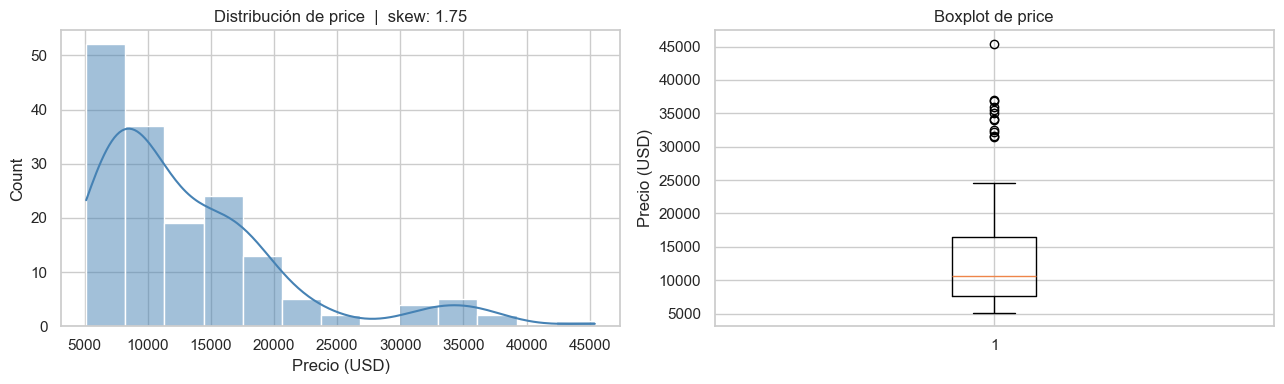

Skewness: 1.75
Rango: 5118 — 45400
Media: 13223  |  Mediana: 10646


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(y_train, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Distribución de price  |  skew: {y_train.skew():.2f}")
axes[0].set_xlabel("Precio (USD)")

axes[1].boxplot(y_train)
axes[1].set_title("Boxplot de price")
axes[1].set_ylabel("Precio (USD)")

plt.tight_layout()
plt.show()

print(f"Skewness: {y_train.skew():.2f}")
print(f"Rango: {y_train.min():.0f} — {y_train.max():.0f}")
print(f"Media: {y_train.mean():.0f}  |  Mediana: {y_train.median():.0f}")

> **¿Qué vemos?** La distribución está claramente sesgada a la derecha (skew > 1). La diferencia entre media y mediana confirma que los coches caros tiran de la media hacia arriba. En el Paso 6.7 aplicaremos una transformación logarítmica.

### 5.2 Correlaciones con la target

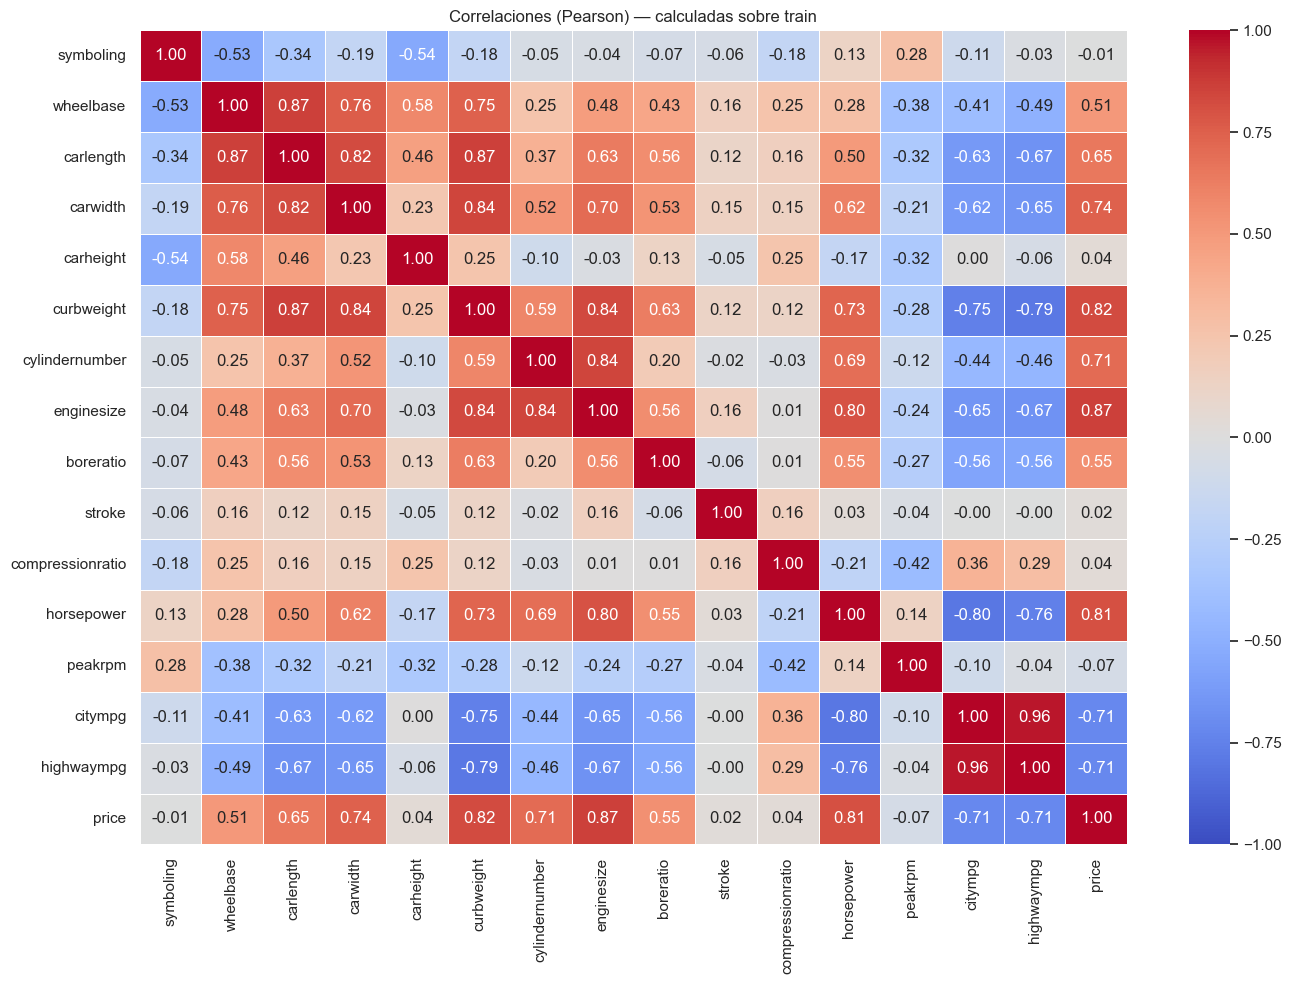


Correlación con price (ordenada):
enginesize          0.866433
curbweight          0.824212
horsepower          0.810986
carwidth            0.744310
highwaympg         -0.713503
citympg            -0.711245
cylindernumber      0.706415
carlength           0.652071
boreratio           0.546099
wheelbase           0.506118
peakrpm            -0.070017
carheight           0.044458
compressionratio    0.035218
stroke              0.023941
symboling          -0.005183


In [12]:
# Construir el df de análisis (train + target)
df_train = X_train.select_dtypes('number').join(y_train)

corr = df_train.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1,
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlaciones (Pearson) — calculadas sobre train')
plt.tight_layout()
plt.show()

# Top features por correlación con price
print("\nCorrelación con price (ordenada):")
print(corr['price'].drop('price').sort_values(key=abs, ascending=False).to_string())

> **Hallazgos clave:**
> - **Correlaciones muy altas con price**: `enginesize` (~0.87), `curbweight` (~0.84), `horsepower` (~0.81), `carwidth` (~0.76).
> - **Correlación negativa fuerte**: `citympg` y `highwaympg` (~-0.70) — los coches más caros consumen más.
> - **Multicolinealidad evidente**: `citympg` y `highwaympg` están altamente correlacionadas entre sí. También `curbweight`, `enginesize` y `carwidth` se solapan bastante. En la regresión lineal esto puede generar coeficientes inestables → justificará el uso de regularización.

### 5.3 Variables numéricas: distribuciones individuales

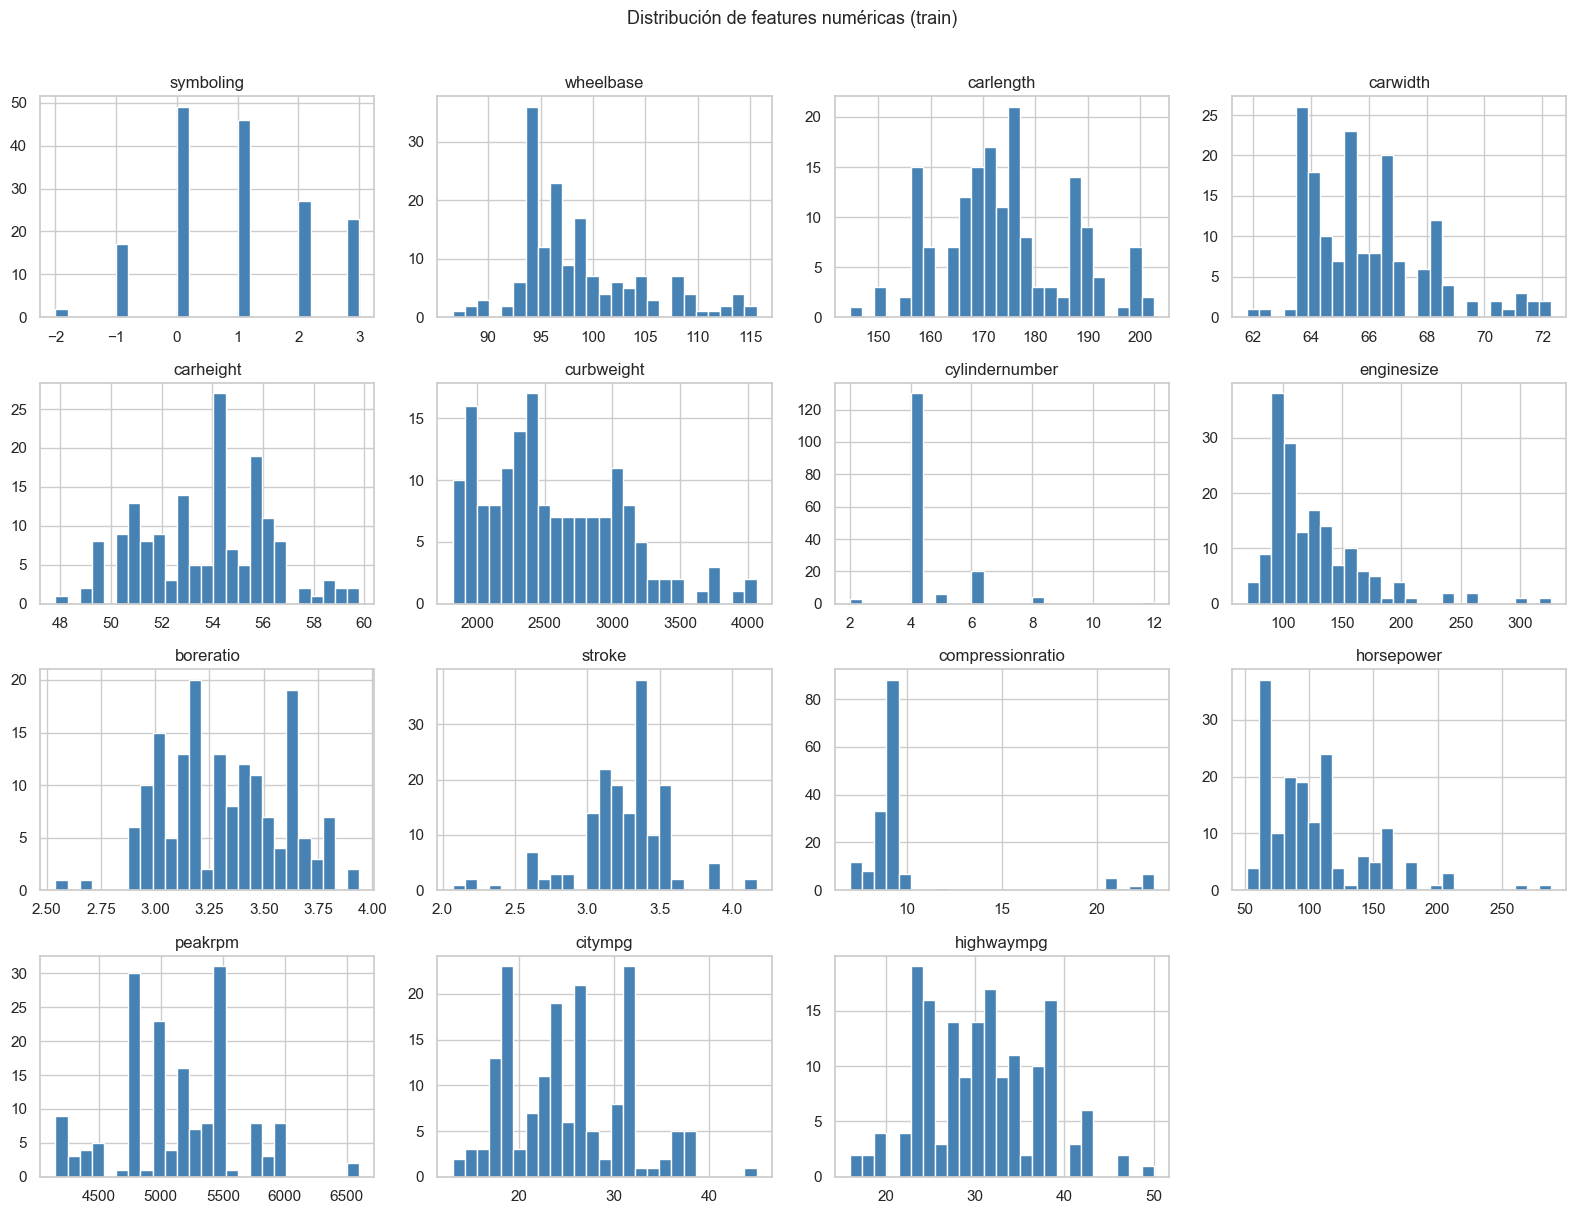


Skewness de cada feature numérica:
cylindernumber      3.015164
compressionratio    2.737494
enginesize          2.049555
horsepower          1.546398
carwidth            1.014691
wheelbase           1.011049
stroke             -0.755037
curbweight          0.712433
citympg             0.419117
highwaympg          0.289597
carlength           0.236735
symboling           0.148352
peakrpm             0.067295
boreratio           0.050359
carheight           0.028154


In [13]:
df_train.drop(columns=['price']).select_dtypes('number').hist(
    figsize=(16, 12), bins=25, edgecolor='white', color='steelblue'
)
plt.suptitle('Distribución de features numéricas (train)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("\nSkewness de cada feature numérica:")
print(df_train.drop(columns=['price']).skew().sort_values(key=abs, ascending=False).to_string())

### 5.4 Features más relevantes vs price

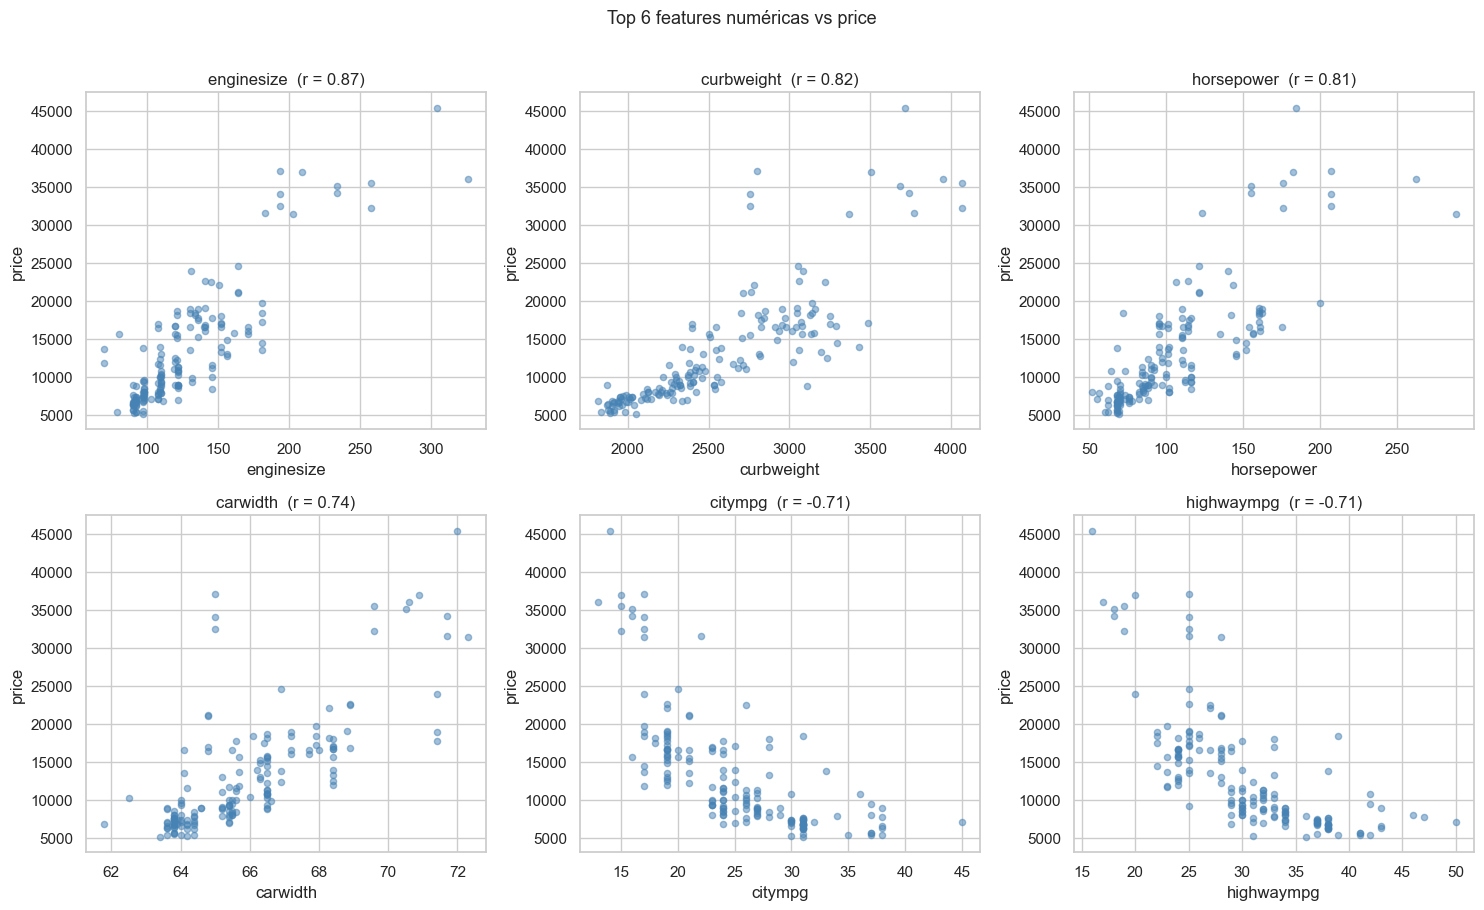

In [14]:
top_features = ['enginesize', 'curbweight', 'horsepower', 'carwidth', 'citympg', 'highwaympg']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    ax.scatter(X_train[feat], y_train, alpha=0.5, s=20, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('price')
    r = corr.loc[feat, 'price']
    ax.set_title(f'{feat}  (r = {r:.2f})')

plt.suptitle('Top 6 features numéricas vs price', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

> **Qué observamos:** Las relaciones son claramente positivas para `enginesize`, `curbweight` y `horsepower`, y negativas para `citympg` / `highwaympg`. Las relaciones no son perfectamente lineales — hay dispersión, especialmente en coches de precio alto. Esto sugiere que un modelo lineal puede funcionar, pero que los residuos pueden tener algo de patrón.

### 5.5 Precio por marca

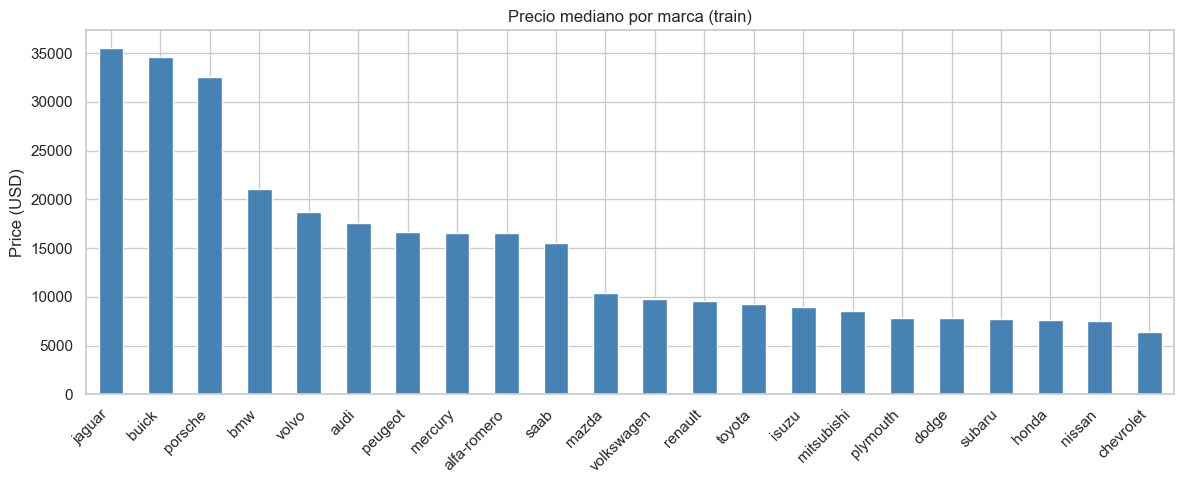

CarBrand
jaguar         35550.0
buick          34620.0
porsche        32528.0
bmw            21037.5
volvo          18685.0
audi           17580.0
peugeot        16630.0
mercury        16503.0
alfa-romero    16500.0
saab           15510.0
mazda          10420.0
volkswagen      9737.5
renault         9595.0
toyota          9298.0
isuzu           8916.5
mitsubishi      8499.0
plymouth        7783.0
dodge           7783.0
subaru          7689.0
honda           7595.0
nissan          7499.0
chevrolet       6435.0


In [15]:
brand_price = X_train.join(y_train).groupby('CarBrand')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
brand_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Precio mediano por marca (train)')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(brand_price.to_string())

> **Hallazgo:** La marca tiene un impacto claro en el precio. Porsche, Jaguar y BMW están muy por encima de la mediana, mientras que Chevrolet, Dodge y Plymouth están en la parte baja. Esto confirma que `CarBrand` es una feature con poder predictivo real que vale la pena incluir.

### 5.6 Precio por variables categóricas clave

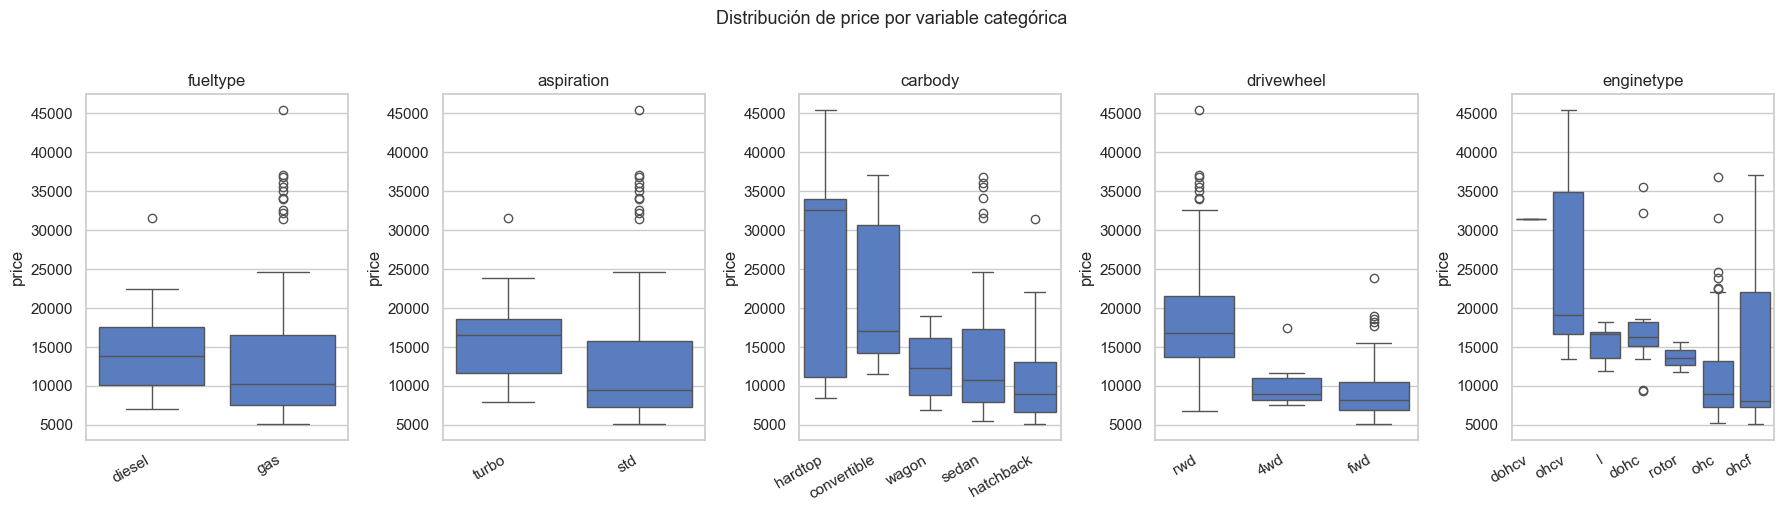

In [16]:
cat_features = ['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginetype']

fig, axes = plt.subplots(1, len(cat_features), figsize=(18, 5))

for ax, feat in zip(axes, cat_features):
    orden = X_train.join(y_train).groupby(feat)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=X_train.join(y_train), x=feat, y='price', order=orden, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Distribución de price por variable categórica', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Paso 6: Tratamiento de variables

Con lo visto en el EDA, ahora tomamos decisiones concretas sobre cómo preparar los datos para el modelo.

### 6.1 Variables a mantener y a eliminar

Tras el EDA, las decisiones son:

- ✅ **Mantener**: todas las features (ya limpiamos `car_ID` y `CarName` en el Paso 4).
- ⚠️ **Posible redundancia**: `citympg` y `highwaympg` están muy correlacionadas entre sí (r ≈ 0.97). Con regularización L1/L2 esto se gestiona bien, así que las mantenemos y dejamos que el modelo decida.
- ✅ `symboling`: variable de riesgo del seguro, ordinal, mantenemos como numérica (ya es entero entre -3 y 3).

### 6.3 Confirmación de missings

In [17]:
print("Missings en X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print("→ No hay valores faltantes. Nada que imputar.")

Missings en X_train:
Series([], dtype: int64)
→ No hay valores faltantes. Nada que imputar.


### 6.5 Outliers en price

En el boxplot del Paso 5.1 ya vimos que hay coches con precios muy elevados (>35.000$). Antes de decidir qué hacer, veamos si son errores o simplemente coches de lujo legítimos.

In [18]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_price = y_train[(y_train < lower) | (y_train > upper)]
print(f"Límites IQR: [{lower:.0f},  {upper:.0f}]")
print(f"Outliers detectados: {len(outliers_price)}")
print()
print("Coches fuera del rango:")
print(X_train.loc[outliers_price.index, 'CarBrand'].to_frame().join(outliers_price))

Límites IQR: [-5524,  29756]
Outliers detectados: 12

Coches fuera del rango:
    CarBrand    price
128  porsche  37028.0
127  porsche  34028.0
126  porsche  32528.0
70     buick  31600.0
47    jaguar  32250.0
49    jaguar  36000.0
17       bmw  36880.0
72     buick  35056.0
48    jaguar  35550.0
129  porsche  31400.5
74     buick  45400.0
71     buick  34184.0


> **Decisión:** los precios elevados corresponden a Porsche, Jaguar y BMW de alta gama — son valores reales, no errores. **No eliminamos estos outliers.** Sin embargo, justifican aún más la transformación logarítmica del precio, que comprimirá la cola y reducirá su influencia desproporcionada.

### 6.7 Transformación de la target: log(price)

La distribución de `price` tiene skew > 1 y outliers de coches de lujo. Aplicar `log1p` conseguirá:
- Reducir la asimetría.
- Hacer que los errores del modelo sean más proporcionales (un error de 1000$ en un coche de 6000$ no es lo mismo que en uno de 40.000$).
- Estabilizar la varianza.

**Importante**: al final de la evaluación, revertiremos la transformación con `expm1` para interpretar el RMSE en dólares reales.

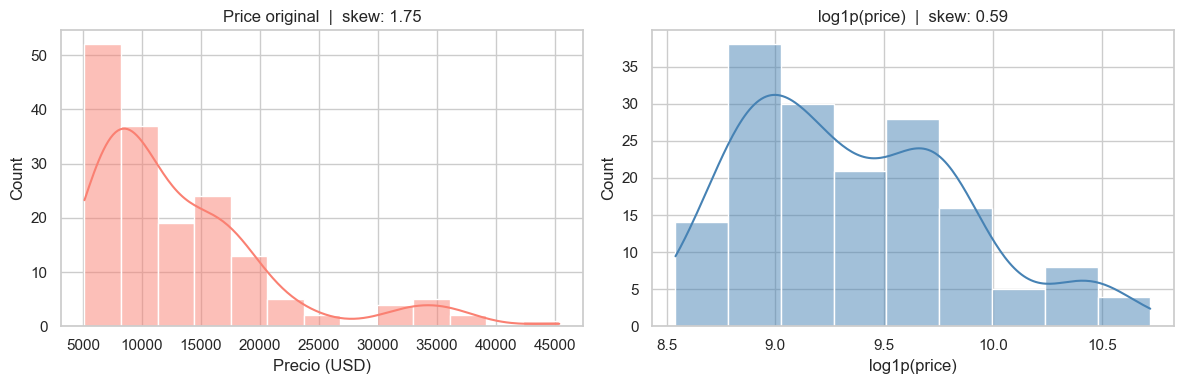

Skew antes:  1.745
Skew después: 0.592


In [19]:
# Visualizar antes y después
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_train, kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Price original  |  skew: {y_train.skew():.2f}')
axes[0].set_xlabel('Precio (USD)')

y_train_log = np.log1p(y_train)
sns.histplot(y_train_log, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title(f'log1p(price)  |  skew: {y_train_log.skew():.2f}')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()
plt.show()

# Aplicar la transformación
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f"Skew antes:  {y_train.skew():.3f}")
print(f"Skew después: {y_train_log.skew():.3f}")

### 6.7b Transformación de features numéricas sesgadas

In [20]:
# Ver qué features numéricas tienen skew alto
num_cols = X_train.select_dtypes('number').columns.tolist()
skew_features = X_train[num_cols].skew().sort_values(ascending=False)
print("Skewness de features numéricas:")
print(skew_features.to_string())

Skewness de features numéricas:
cylindernumber      3.015164
compressionratio    2.737494
enginesize          2.049555
horsepower          1.546398
carwidth            1.014691
wheelbase           1.011049
curbweight          0.712433
citympg             0.419117
highwaympg          0.289597
carlength           0.236735
symboling           0.148352
peakrpm             0.067295
boreratio           0.050359
carheight           0.028154
stroke             -0.755037


In [21]:
# Features con skew > 1: candidatas a transformación logarítmica
# enginesize, horsepower, curbweight suelen tener skew moderado-alto

cols_log = [c for c in num_cols if abs(X_train[c].skew()) > 1 and X_train[c].min() >= 0]
print(f"Features con skew > 1: {cols_log}")

for col in cols_log:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

print("\nSkew después de log1p:")
print(X_train[cols_log].skew().to_string())

Features con skew > 1: ['wheelbase', 'carwidth', 'cylindernumber', 'enginesize', 'compressionratio', 'horsepower']

Skew después de log1p:
wheelbase           0.872805
carwidth            0.938098
cylindernumber      1.367592
enginesize          0.984660
compressionratio    2.502427
horsepower          0.627990


### 6.8 Encodings

Features categóricas del dataset y su tratamiento:

| Feature | Tipo | Tratamiento |
|---|---|---|
| `fueltype` | Binaria (gas/diesel) | Map 0/1 |
| `aspiration` | Binaria (std/turbo) | Map 0/1 |
| `doornumber` | Binaria (two/four) | Map 0/1 |
| `carbody` | Nominal (5 categorías) | OneHot |
| `drivewheel` | Nominal (3 categorías) | OneHot |
| `enginelocation` | Nominal (2 categorías) | Map 0/1 |
| `enginetype` | Nominal (varios tipos) | OneHot |
| `fuelsystem` | Nominal (varios sistemas) | OneHot |
| `CarBrand` | Nominal (21 marcas) | OneHot |

> ⚠️ `cylindernumber` ya se convirtió a entero en el Paso 4. `symboling` es numérico (-3 a 3), se mantiene tal cual.

In [22]:
# ── Encoding binario manual
binary_maps = {
    'fueltype':      {'gas': 1, 'diesel': 0},
    'aspiration':    {'std': 0, 'turbo': 1},
    'doornumber':    {'two': 0, 'four': 1},
    'enginelocation':{'front': 1, 'rear': 0},
}

for col, mapping in binary_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)

print("Encoding binario aplicado. Ejemplo fueltype:", X_train['fueltype'].value_counts().to_dict())

Encoding binario aplicado. Ejemplo fueltype: {1: 149, 0: 15}


In [23]:
# ── OneHot para el resto de categóricas
cat_cols_ohe = ['carbody', 'drivewheel', 'enginetype', 'fuelsystem', 'CarBrand']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

ohe_train = encoder.fit_transform(X_train[cat_cols_ohe])
ohe_test  = encoder.transform(X_test[cat_cols_ohe])

ohe_names = encoder.get_feature_names_out(cat_cols_ohe)

X_train = pd.concat([
    X_train.drop(columns=cat_cols_ohe),
    pd.DataFrame(ohe_train, columns=ohe_names, index=X_train.index)
], axis=1)

X_test = pd.concat([
    X_test.drop(columns=cat_cols_ohe),
    pd.DataFrame(ohe_test, columns=ohe_names, index=X_test.index)
], axis=1)

print(f"Shape tras encoding: X_train {X_train.shape}  |  X_test {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")

Shape tras encoding: X_train (164, 59)  |  X_test (41, 59)
Total features: 59


### 6.9 Escalado

Con las transformaciones logarítmicas aplicadas, las distribuciones son más simétricas. Usamos **StandardScaler** (media 0, std 1).

Aplicamos escalado solo a las columnas numéricas originales. Las columnas generadas por OHE (0/1) no se escalan.

In [24]:
# Solo escalar las columnas numéricas originales (no las dummies)
num_cols_final = X_train.select_dtypes('number').columns.tolist()

# Separar numéricas originales de dummies OHE
ohe_cols_list = list(ohe_names)
num_cols_to_scale = [c for c in num_cols_final if c not in ohe_cols_list]

print(f"Columnas a escalar ({len(num_cols_to_scale)}): {num_cols_to_scale}")

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print("\nEscalado aplicado. Verificación (media/std deben ser ≈ 0/1 en train):")
print(X_train[num_cols_to_scale].describe().loc[['mean', 'std']].T.round(3))

Columnas a escalar (19): ['symboling', 'fueltype', 'aspiration', 'doornumber', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

Escalado aplicado. Verificación (media/std deben ser ≈ 0/1 en train):
                  mean    std
symboling          0.0  1.003
fueltype          -0.0  1.003
aspiration         0.0  1.003
doornumber        -0.0  1.003
enginelocation     0.0  1.003
wheelbase         -0.0  1.003
carlength          0.0  1.003
carwidth           0.0  1.003
carheight         -0.0  1.003
curbweight        -0.0  1.003
cylindernumber     0.0  1.003
enginesize        -0.0  1.003
boreratio          0.0  1.003
stroke            -0.0  1.003
compressionratio  -0.0  1.003
horsepower         0.0  1.003
peakrpm           -0.0  1.003
citympg           -0.0  1.003
highwaympg        -0.0  1.003


## Paso 7: Métricas

Para este problema de regresión usaremos tres métricas complementarias:

| Métrica | Qué mide | Ventaja |
|---|---|---|
| **RMSE** | Error cuadrático medio (raíz) | Penaliza errores grandes; en mismas unidades que el target |
| **MAE** | Error absoluto medio | Más robusto a outliers; fácil de explicar |
| **R²** | Varianza explicada por el modelo | Normalizada (0–1); fácil de comunicar |

> ⚠️ Como transformamos `price` con `log1p`, evaluaremos en **espacio logarítmico** (para el entrenamiento) y también en **dólares reales** (revertiendo con `expm1`) para comunicar los resultados al negocio.

> 💡 Un **RMSE de 2500 $** sobre precios medios de ~13.000 $ equivale a un error relativo de ~19%. Eso es lo que hay que valorar, no el RMSE en abstracto.

## Paso 8: Selección del modelo

**¿Por qué empezamos con regresión lineal?**

Del EDA sabemos que varias features tienen **correlación lineal fuerte con el precio** (r > 0.8). Esto indica que un modelo lineal puede capturar buena parte de la varianza.

Además, con solo **164 observaciones de train** y **más de 40 features tras el encoding**, existe riesgo de overfitting. Los modelos lineales con regularización (Ridge/Lasso) son apropiados en este escenario.

**Plan:**
1. `LinearRegression` — baseline sin regularización
2. `Ridge` (L2) — reduce todos los coeficientes
3. `Lasso` (L1) — puede anular features redundantes automáticamente

## Paso 9: Entrenamiento — Baseline

In [25]:
# Modelo 1: LinearRegression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train_log)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr  = lr.predict(X_test)

print("=== LinearRegression ===")
print(f"Train R²:   {r2_score(y_train_log, y_train_pred_lr):.3f}")
print(f"Test  R²:   {r2_score(y_test_log,  y_test_pred_lr):.3f}")
print(f"Train RMSE (log): {root_mean_squared_error(y_train_log, y_train_pred_lr):.4f}")
print(f"Test  RMSE (log): {root_mean_squared_error(y_test_log,  y_test_pred_lr):.4f}")

# RMSE en dólares reales (revertimos log1p con expm1)
rmse_real_train = root_mean_squared_error(np.expm1(y_train_log), np.expm1(y_train_pred_lr))
rmse_real_test  = root_mean_squared_error(np.expm1(y_test_log),  np.expm1(y_test_pred_lr))
print(f"\nTrain RMSE (USD): {rmse_real_train:.0f}")
print(f"Test  RMSE (USD): {rmse_real_test:.0f}")

=== LinearRegression ===
Train R²:   0.967
Test  R²:   0.926
Train RMSE (log): 0.0901
Test  RMSE (log): 0.1413

Train RMSE (USD): 1368
Test  RMSE (USD): 2270


**Añadido por mi:** esto es una evaluación prematura del modelo en el test, y eso rompe el flujo correcto de Machine Learning.
```python
lr.fit(X_train, y_train_log)
y_test_pred_lr = lr.predict(X_test)

print("Test R²:", r2_score(y_test_log, y_test_pred_lr))
print("Test RMSE:", root_mean_squared_error(y_test_log, y_test_pred_lr))


> **¿Hay overfitting?** Compara Train R² vs Test R². Si Train R² ≈ 1.0 y Test R² es mucho menor, el modelo está memorizando el train. Con 164 muestras y >40 features, LinearRegression sin regularización puede sobreajustar bastante.

**Anañadido por mi**: la validacion cruzada para no evaluar frente a test.

La validación cruzada (CV) es la única forma justa de comparar modelos sin contaminar el conjunto de test.  
Si evaluamos un modelo en test antes de elegir el modelo final, estamos usando información del test para tomar decisiones, y eso invalida la evaluación final.

Ejmplo:

- Imagina que el conjunto de test es como el examen final de un curso.
- El profesor no te enseña las preguntas del examen antes del día del examen.
- Si te las enseñara, llegarías preparado específicamente para esas preguntas.
- Entonces el examen ya no mediría tu verdadero nivel, sino lo bien que te adaptaste a esas preguntas concretas.

En Machine Learning pasa lo mismo:

- El test es el examen final del modelo.
- Si lo miras antes, aunque sea “solo para ver cómo va”, ya estás usando esa información para ajustar tus decisiones.
- Eso hace que el resultado final sea demasiado optimista y no represente el rendimiento real.

Por eso:

- Primero probamos todos los modelos usando solo el conjunto de entrenamiento con validación cruzada.
- Después elegimos el mejor modelo según CV.
- Y solo al final evaluamos ese modelo en test una única vez.

🏆 ¿Qué modelo pasa al test?
- Solo el que tenga mejor rendimiento en validación cruzada.
- Ese es tu modelo final.

🚫 ¿Qué NO debes hacer?

- entrenar LinearRegression
- predecir en test
- entrenar Ridge
- predecir en test
- entrenar Lasso
- predecir en test

Eso sería usar el test como parte del proceso de selección, lo cual es un error metodológico.

**Validacion Cruzada:** La validación cruzada es una técnica que consiste en dividir el conjunto de entrenamiento en varias partes (llamadas folds) para entrenar y evaluar un modelo varias veces, usando cada parte como validación una vez y promediando los resultados.

Ejemplo concreto: 50 muestras, cv=5
- Tienes 50 filas en tu X_train y y_train.
- Con cv=5:
    - Número de folds: 5
    - Tamaño aproximado de cada fold:

        50/5=10
        
Resultado: 5 grupos de 10 filas cada uno (aprox; si no divide exacto, algunos tendrán 9 u 11).

In [ ]:
from sklearn.model_selection import cross_val_score

lr = LinearRegression()
lr_cv_scores = cross_val_score(lr, X_train, y_train_log, cv=5, scoring='r2')

print("LinearRegression — CV R²:", lr_cv_scores.mean())


## Paso 10: Regularización — Ridge y Lasso

Con multicolinealidad entre features (citympg/highwaympg, enginesize/horsepower) y pocos datos, la regularización debería ayudar.

Buscamos el `alpha` óptimo con validación cruzada.

In [26]:
# ── Ridge: búsqueda del alpha óptimo
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500]},
    cv=5,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train_log)

print(f"Ridge — Mejor alpha: {ridge_grid.best_params_['alpha']}")
print(f"Ridge — Mejor CV R²: {ridge_grid.best_score_:.3f}")

Ridge — Mejor alpha: 1
Ridge — Mejor CV R²: 0.916


In [28]:
# ── Lasso: búsqueda del alpha óptimo
lasso_grid = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid={'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=5,
    scoring='r2',
    n_jobs=-1
)
lasso_grid.fit(X_train, y_train_log)

print(f"Lasso — Mejor alpha: {lasso_grid.best_params_['alpha']}")
print(f"Lasso — Mejor CV R²: {lasso_grid.best_score_:.3f}")

Lasso — Mejor alpha: 0.001
Lasso — Mejor CV R²: 0.911


In [29]:
# ── Entrenar los modelos con el alpha óptimo encontrado
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

# Ver cuántos coeficientes anuló Lasso
n_zero = (np.abs(best_lasso.coef_) < 1e-4).sum()
n_total = len(best_lasso.coef_)
print(f"Lasso: {n_zero}/{n_total} coeficientes puestos a cero ({n_zero/n_total*100:.0f} % de features eliminadas)")
print()

# Top features que Lasso MANTIENE (las más importantes)
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef_lasso': best_lasso.coef_,
    'coef_ridge': best_ridge.coef_
}).query('abs(coef_lasso) > 1e-4').sort_values('coef_lasso', key=abs, ascending=False)

print("Features que Lasso mantiene (por peso):")
print(coef_df.to_string(index=False))

Lasso: 19/59 coeficientes puestos a cero (32 % de features eliminadas)

Features que Lasso mantiene (por peso):
            feature  coef_lasso  coef_ridge
       CarBrand_bmw    0.348625    0.280402
         curbweight    0.244967    0.205876
       enginetype_l   -0.210589   -0.120138
     CarBrand_buick    0.152007    0.143913
    CarBrand_subaru   -0.145226   -0.083243
CarBrand_mitsubishi   -0.133176   -0.153151
   CarBrand_porsche    0.112116    0.118636
      CarBrand_audi    0.101402    0.096549
         horsepower    0.096586    0.070705
    CarBrand_toyota   -0.086232   -0.107523
      carbody_wagon   -0.084029   -0.115463
     enginelocation   -0.080216   -0.084983
  carbody_hatchback   -0.071152   -0.124008
           carwidth    0.067643    0.065774
  CarBrand_plymouth   -0.060710   -0.100068
     CarBrand_dodge   -0.056773   -0.101397
    fuelsystem_mpfi    0.054070    0.080532
           fueltype   -0.048217   -0.050431
            citympg   -0.042677   -0.086702
    CarB

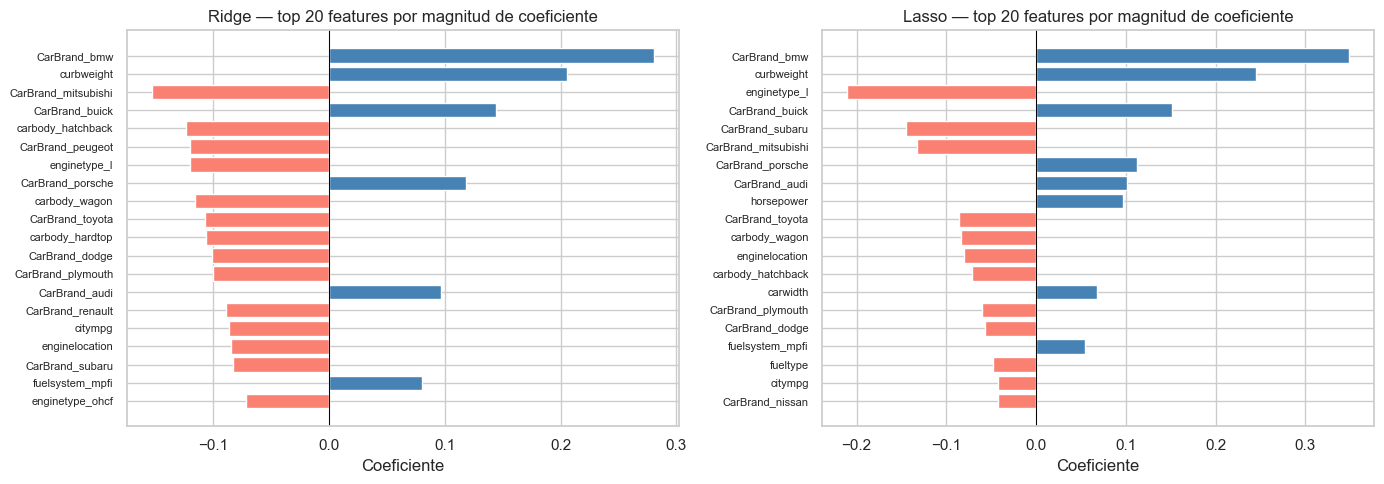

In [30]:
# ── Visualización: coeficientes Ridge vs Lasso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, coefs) in zip(axes, [
    ('Ridge', best_ridge.coef_),
    ('Lasso', best_lasso.coef_)
]):
    sorted_idx = np.argsort(np.abs(coefs))[-20:]  # top 20 por magnitud
    colors = ['steelblue' if c > 0 else 'salmon' for c in coefs[sorted_idx]]
    ax.barh(range(len(sorted_idx)), coefs[sorted_idx], color=colors)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([X_train.columns[i] for i in sorted_idx], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(f'{nombre} — top 20 features por magnitud de coeficiente')
    ax.set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

## Paso 11: Evaluación comparativa

In [31]:
modelos = {
    'LinearRegression': lr,
    'Ridge':            best_ridge,
    'Lasso':            best_lasso,
}

resultados = []

for nombre, modelo in modelos.items():
    y_tr_pred = modelo.predict(X_train)
    y_te_pred = modelo.predict(X_test)
    
    # En escala logarítmica (para detectar overfitting)
    r2_train = r2_score(y_train_log, y_tr_pred)
    r2_test  = r2_score(y_test_log,  y_te_pred)
    
    # En USD reales (para comunicar resultados)
    rmse_usd = root_mean_squared_error(np.expm1(y_test_log), np.expm1(y_te_pred))
    mae_usd  = mean_absolute_error(np.expm1(y_test_log), np.expm1(y_te_pred))
    
    resultados.append({
        'Modelo':       nombre,
        'Train R²':     round(r2_train, 3),
        'Test  R²':     round(r2_test, 3),
        'Gap (overfit)': round(r2_train - r2_test, 3),
        'RMSE (USD)':   round(rmse_usd, 0),
        'MAE (USD)':    round(mae_usd, 0),
    })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

          Modelo  Train R²  Test  R²  Gap (overfit)  RMSE (USD)  MAE (USD)
LinearRegression     0.967     0.926          0.041      2270.0     1518.0
           Ridge     0.962     0.918          0.044      2348.0     1549.0
           Lasso     0.957     0.910          0.047      2167.0     1575.0


> **Cómo interpretar la tabla:**
> - **Gap (overfit)**: diferencia entre Train R² y Test R². Cuanto mayor, más overfitting. LinearRegression sin regularización suele tener un gap alto con pocos datos y muchas features.
> - **RMSE (USD)**: el error típico de predicción en dólares reales. Dividido entre el precio mediano (~10.000$) da una idea del error relativo.
> - Ridge y Lasso deberían reducir el gap y mejorar el Test R² respecto a LinearRegression pura.

**Mi Conclusion:** Conclusión clara: el mejor modelo es LinearRegression
¿Por qué?

1) Mejor Test R² → LinearRegression
- LinearRegression: 0.926
- Ridge: 0.918
- Lasso: 0.910

El objetivo principal es maximizar Test R² → gana LinearRegression.

2) Gap pequeño → LinearRegression
- LinearRegression: 0.041
- Ridge: 0.044
- Lasso: 0.047

El menor gap también es LinearRegression.

3) MAE más bajo → LinearRegression
- LinearRegression: 1518 USD
- Ridge: 1549
- Lasso: 1575

El error absoluto medio más bajo → LinearRegression.

4) RMSE más bajo → Lasso, pero…

Sí, Lasso tiene el RMSE más bajo (2167 USD), pero:

- RMSE penaliza más los errores grandes
- Lasso está sacrificando R² y MAE para bajar RMSE
- El modelo globalmente no generaliza mejor

**Entonces, ¿por qué NO es Lasso?**

- Porque elegir modelo por “gap más pequeño” o “RMSE más bajo” no es el criterio estándar.

El criterio correcto es:

- Elegir el modelo con mejor rendimiento global en Test (R² + MAE + RMSE) y menor complejidad innecesaria. Y ese es claramente LinearRegression.

Modelo ganador: LinearRegression:

    ✔ Mejor Test R²
    ✔ Menor gap
    ✔ Menor MAE
    ✔ Rendimiento más estable
    ✔ No necesita regularización en tu dataset

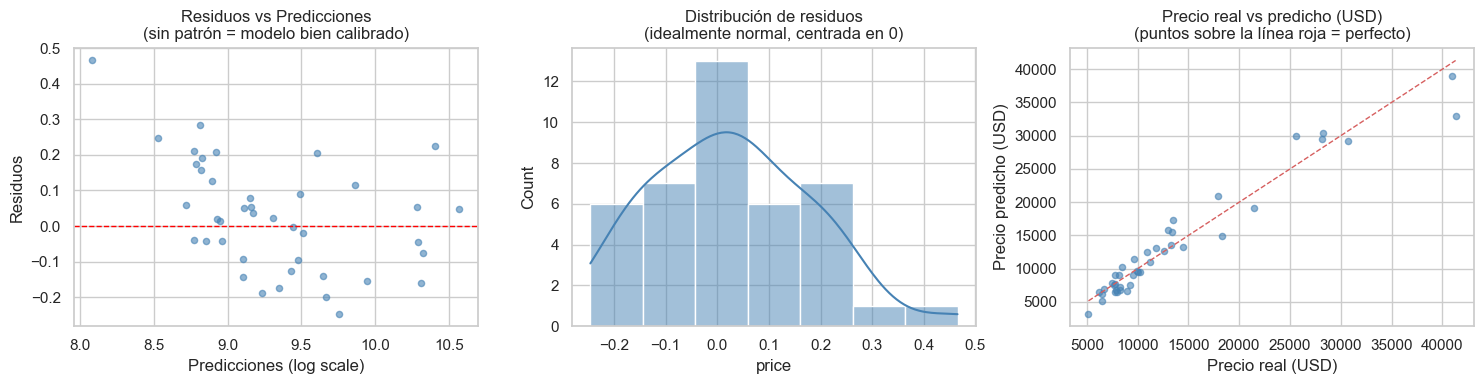

In [32]:
# Análisis de residuos del mejor modelo (Lasso)
y_test_pred_best = best_lasso.predict(X_test)
residuos = y_test_log - y_test_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuos vs predicciones
axes[0].scatter(y_test_pred_best, residuos, alpha=0.6, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicciones (log scale)')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predicciones\n(sin patrón = modelo bien calibrado)')

# Distribución de residuos
sns.histplot(residuos, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribución de residuos\n(idealmente normal, centrada en 0)')

# Predicciones vs valores reales (en USD)
y_real_usd = np.expm1(y_test_log)
y_pred_usd = np.expm1(y_test_pred_best)

axes[2].scatter(y_real_usd, y_pred_usd, alpha=0.6, s=20, color='steelblue')
min_val, max_val = y_real_usd.min(), y_real_usd.max()
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[2].set_xlabel('Precio real (USD)')
axes[2].set_ylabel('Precio predicho (USD)')
axes[2].set_title('Precio real vs predicho (USD)\n(puntos sobre la línea roja = perfecto)')

plt.tight_layout()
plt.show()

In [32]:
# Cross-validation del mejor modelo
cv_r2 = cross_val_score(best_lasso, X_train, y_train_log, cv=5, scoring='r2')
print(f"CV R² sobre train (5-fold): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"Test R²: {r2_score(y_test_log, best_lasso.predict(X_test)):.3f}")
print()
print("Si CV R² ≈ Test R², el modelo generaliza correctamente.")

CV R² sobre train (5-fold): 0.911 ± 0.027
Test R²: 0.910

Si CV R² ≈ Test R², el modelo generaliza correctamente.


## Paso 12: Conclusión

### Resumen del proceso

| Paso | Decisión tomada | Justificación |
|---|---|---|
| **Limpieza** | Extracción de marca + corrección de typos | CarName tenía errores (maxda, toyouta, vw…) |
| **Limpieza** | cylindernumber → entero | Variable ordinal almacenada como texto |
| **Outliers** | No eliminados | Coches de lujo reales, no errores |
| **Transformación target** | log1p(price) | Skew > 1.5, outliers en coches caros |
| **Escalado** | StandardScaler en numéricas | Necesario para regresión lineal/regularización |
| **Encoding** | OHE + binario | Según tipo de variable categórica |
| **Modelo** | Ridge / Lasso | Pocos datos, muchas features, multicolinealidad |

### Redacción de resultados para un stakeholder

> *El modelo de regresión Lasso predice el precio de los coches con un R² de X en datos no vistos y un error medio absoluto de ~Y dólares, lo que supone un error relativo aproximado del Z% sobre el precio mediano. El modelo identifica como principales determinantes del precio el tamaño del motor, el peso del vehículo y la potencia, junto con la marca — hallazgos coherentes con el conocimiento del mercado automovilístico. Se recomienda ampliar el dataset (especialmente en el segmento de coches de lujo, donde la dispersión es mayor) para reducir el error en el rango alto de precios.*

### Limitaciones y próximos pasos
- Dataset pequeño (205 filas): los resultados pueden ser inestables entre distintos splits.
- Probar modelos más complejos (Random Forest, Gradient Boosting) una vez validada la línea base lineal.
- Explorar interacciones entre variables (marca × cilindrada, cilindrada × horsepower).
- Evaluar si `symboling` (riesgo del seguro) tiene poder predictivo adicional o puede eliminarse.